# 01 — Build the Inflation Credibility Factor

### What the factor measures

One line answering: **how much does the market believe the Fed will
actually keep inflation under control?** When belief is strong the factor
is high; when the market doubts the Fed's follow-through it bleeds lower.
Around hawkish policy surprises (like the June 2026 FOMC) it spikes, and
if action doesn't follow words, it unwinds.

### The method

Six market series, each turned into a **21-day exponentially weighted
z-score**, each given an economic **sign**, then combined as an
**equal-weighted average**. Why each sign makes economic sense:

| Component | Bloomberg ticker | Sign | Logic: credibility UP means... |
|---|---|---|---|
| July FOMC hike pricing | built from `FFQ6 Comdty` + `FEDL01 Index` | + | market prices the Fed to actually hike |
| 30y yields | `USGG30YR Index` | − | long-term inflation premium stays anchored, yields fall |
| 5y inflation swaps | `USSWIT5 Curncy` | − | expected inflation falls |
| Dollar | `DXY Curncy` | + | credibly tight policy = stronger dollar |
| Gold | `XAU Curncy` | − | less need for the inflation hedge |
| Oil | `CL1 Comdty` | − | inflation pressure easing |

Equal weights keep the factor honest: no component is privileged, and any
move in the factor decomposes exactly into six visible contributions
(notebook 02 uses that for attribution).

**The FOMC pricing leg:** fed funds futures settle on the average
effective rate in their month. `FFQ6 Comdty` is the **August 2026**
contract — the first month fully after the July FOMC — so
`(100 − price) − current effective rate (FEDL01)` ≈ how many bp of
hike are priced for the July meeting. (With meeting-dated OIS
entitlement, those tickers are a cleaner swap-in.)

In [1]:
import datetime as dt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import bbg

if bbg.MOCK_MODE:
    print("MOCK MODE: synthetic data with a planted spike-and-unwind pattern.")
    print("Same code pulls real data once blpapi + Terminal are available.")
else:
    print("Pulling REAL Bloomberg data.")

START = dt.date(2025, 1, 1)
END = dt.date.today()

TICKERS = ["USGG30YR Index", "USSWIT5 Curncy", "DXY Curncy",
           "XAU Curncy", "CL1 Comdty", "FFQ6 Comdty", "FEDL01 Index"]

raw = bbg.bdh(TICKERS, "PX_LAST", START, END).ffill().dropna()
print(raw.tail(3).round(2))

MOCK MODE: synthetic data with a planted spike-and-unwind pattern.
Same code pulls real data once blpapi + Terminal are available.
            USGG30YR Index  USSWIT5 Curncy  DXY Curncy  XAU Curncy  \
2026-07-08            4.70            2.46      101.16     2842.24   
2026-07-09            4.79            2.40      100.23     2837.81   
2026-07-10            4.76            2.42      102.01     2839.37   

            CL1 Comdty  FFQ6 Comdty  FEDL01 Index  
2026-07-08       67.82        95.57          4.33  
2026-07-09       67.28        95.62          4.33  
2026-07-10       67.45        95.58          4.34  


### Build the six component series

Five are used as-is. The sixth (FOMC hike pricing, in basis points) is
computed from the futures price the way described above.

In [2]:
hike_bp = ((100.0 - raw["FFQ6 Comdty"]) - raw["FEDL01 Index"]) * 100.0

components = pd.DataFrame({
    "fomc_hike": hike_bp,
    "yield_30y": raw["USGG30YR Index"],
    "infl_swap_5y": raw["USSWIT5 Curncy"],
    "dxy": raw["DXY Curncy"],
    "gold": raw["XAU Curncy"],
    "oil": raw["CL1 Comdty"],
})

# credibility sign of each component (see the table above)
SIGNS = {"fomc_hike": +1, "yield_30y": -1, "infl_swap_5y": -1,
         "dxy": +1, "gold": -1, "oil": -1}

print(components.tail(3).round(2))

            fomc_hike  yield_30y  infl_swap_5y     dxy     gold    oil
2026-07-08      10.25       4.70          2.46  101.16  2842.24  67.82
2026-07-09       4.85       4.79          2.40  100.23  2837.81  67.28
2026-07-10       8.26       4.76          2.42  102.01  2839.37  67.45


### The 21-day exponentially weighted z-score

A normal z-score asks "how far is today's value from average, in units
of standard deviation?". The *exponentially weighted* version computes
that average and standard deviation giving **recent days more weight**,
fading out with a 21-day half-life:

```
z_t = (x_t - ewm_mean_t) / ewm_std_t
```

pandas does the weighting for us with `.ewm(halflife=21)`.
("21 day exponentially weighted" could also be implemented as `span=21`
— a faster fade. It is one line to flip; the shape barely changes.)

In [3]:
HALFLIFE = 21

def ewm_zscore(series, halflife=HALFLIFE):
    """Exponentially weighted z-score of a series' LEVEL."""
    mean = series.ewm(halflife=halflife).mean()
    std = series.ewm(halflife=halflife).std()
    return (series - mean) / std


zscores = pd.DataFrame({name: ewm_zscore(components[name])
                        for name in components.columns}).dropna()

# apply the credibility signs, so every column is "positive = credible"
signed_z = pd.DataFrame({name: zscores[name] * SIGNS[name]
                         for name in zscores.columns})

### Combine: the factor = equal-weighted average of the six signed z-scores

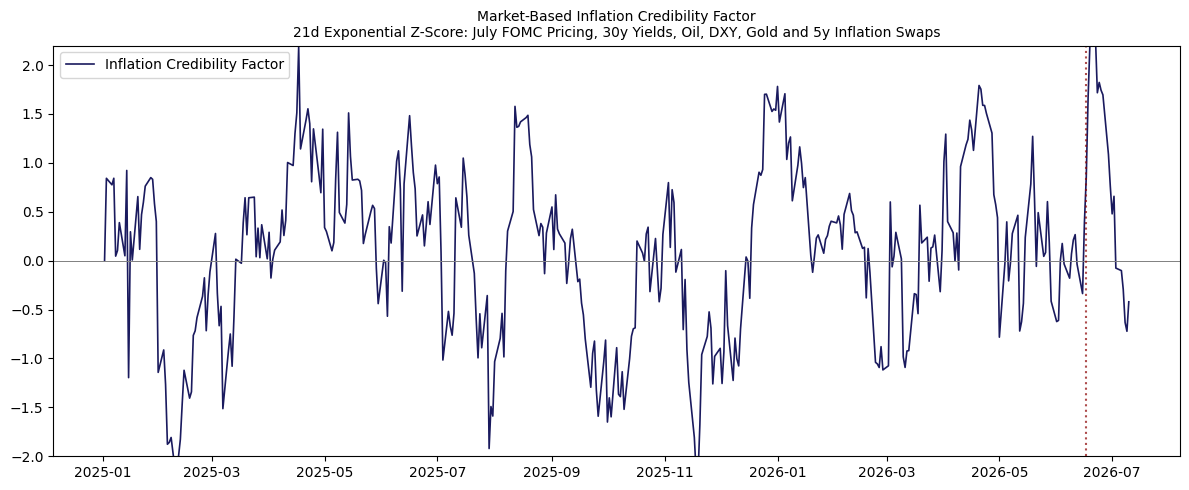

In [4]:
factor = signed_z.mean(axis=1)
factor.name = "Inflation Credibility Factor"

fomc_date = pd.Timestamp(2026, 6, 17)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(factor.index, factor.values, color="#1a1a5e", linewidth=1.2,
        label="Inflation Credibility Factor")
ax.axhline(0, color="grey", linewidth=0.7)
if factor.index[-1] >= fomc_date:
    ax.axvline(fomc_date, color="darkred", linestyle=":", alpha=0.7)
    ax.annotate("June FOMC", xy=(fomc_date, factor.max()),
                xytext=(10, 0), textcoords="offset points", color="darkred")
ax.set_ylim(-2, 2.2)
ax.set_title("Market-Based Inflation Credibility Factor\n"
             "21d Exponential Z-Score: July FOMC Pricing, 30y Yields, Oil, DXY, "
             "Gold and 5y Inflation Swaps", fontsize=10)
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("factor_recreation.png", dpi=120)
plt.show()

**Sanity checks:** the factor should oscillate roughly in a ±1 band
(it is an average of six correlated z-scores), spike toward ~2 on major
hawkish surprises, and mean-revert rather than trend — a z-score cannot
drift forever because its own mean and std adapt.

In [5]:
# cache everything so notebook 02 doesn't need Bloomberg again
signed_z.to_csv("signed_zscores.csv")
factor.to_frame().to_csv("factor.csv")
print("Saved signed_zscores.csv and factor.csv")
print(f"\nLatest factor value: {factor.iloc[-1]:+.2f}")
if factor.index[-1] >= fomc_date:
    print(f"Peak since June FOMC: {factor[factor.index >= fomc_date].max():+.2f}")

Saved signed_zscores.csv and factor.csv

Latest factor value: -0.42
Peak since June FOMC: +2.26


### Each component's contribution (stacked view)

Because the factor is the average of six signed z-scores, each component
contributes `signed_z / 6`. Plotting them stacked shows WHO is driving
the factor at any moment — e.g. whether an unwind is a rates story, an
oil story, or broad-based.

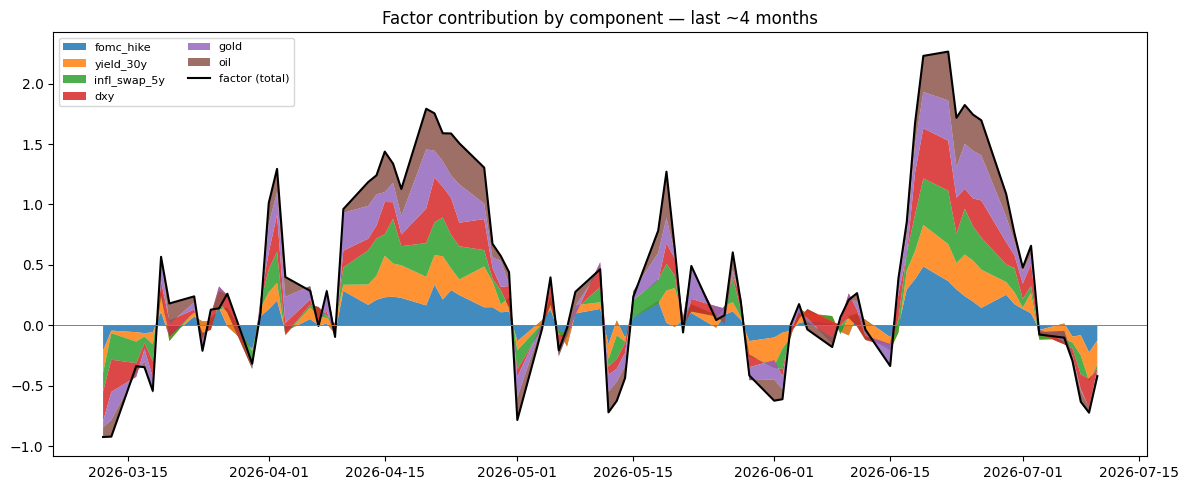

In [6]:
contrib = signed_z / 6.0
recent = contrib.loc[contrib.index >= contrib.index[-1] - pd.Timedelta(days=120)]

fig, ax = plt.subplots(figsize=(12, 5))
ax.stackplot(recent.index, [recent[c].values for c in recent.columns],
             labels=list(recent.columns), alpha=0.85)
ax.plot(recent.index, recent.sum(axis=1), color="black", linewidth=1.5,
        label="factor (total)")
ax.axhline(0, color="grey", linewidth=0.7)
ax.set_title("Factor contribution by component — last ~4 months")
ax.legend(loc="upper left", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()